# Building a ConvNP Model for NZRA data over Auckland

We have been provided NZRA data from the Auckland region, which provides a much higher-resolution view than ERA5. Additionally, more weather stations are available in the stations_v2 dataset, and data from the Himawari8 satellite is available. Using this new data, we want to build and validate a ConvNP for data assimilation at weather stations, with NZRA and H8 data as context sets.

In [1]:
# setup project root for imports (requirement for all notebooks in this repo)
import sys
from pathlib import Path

# Make project root importable
ROOT = Path().resolve().parents[1]
sys.path.append(str(ROOT))

In [2]:
# setup logging (useful for running with nohup)
from src.config.logging_config import setup_logging
import logging

setup_logging()  # configure logging
logger = logging.getLogger(__name__)
logger.info("Notebook execution started.")

# setup tensorboard logging
from torch.utils.tensorboard import SummaryWriter
from datetime import datetime

TB_TRAIN_LOSS = "Loss/Train"
TB_VAL_LOSS = "Loss/Validation"
TB_EXPERIMENT = "exp4_nzra"

tb_writer = SummaryWriter(log_dir=str(ROOT / ".tb_logs" / TB_EXPERIMENT / f"run_s1_{datetime.now().strftime('%d-%m %H:%M')}"))

2025-12-09 16:24:18 - INFO - __main__ - Notebook execution started.


In [3]:
%load_ext autoreload

In [4]:
%autoreload 2
from src.utils.variables.var_names import *
from src.utils.variables.coord_names import *
from src.data_processing.conversions.scalar_conversions import *
from src.config.env_loader import get_env_var
import src.learning.model_diagnostics as model_diagnostics
from src.learning.model_training import batch_data_by_num_stations, compute_val_loss

from src.data_processing.station_processor import ProcessStations
from src.data_processing.topography_processor import ProcessTopography
from src.data_processing.nzra_processor import ProcessNZRA
from src.data_processing.himawari8_processor import ProcessHimawari8

from src.data_processing.auxiliary.sun_position import get_sun_culmination, get_sun_position
from src.data_processing.auxiliary.positional_encodings import build_cropped_auxiliary

In [5]:
# DeepSensor imports
# note this pulls from a fork of DeepSensor.
import deepsensor.torch
from deepsensor.train.train import train_epoch, set_gpu_default_device, concat_tasks
from deepsensor.data.loader import TaskLoader
from deepsensor.data.processor import DataProcessor
from deepsensor.model.convnp import ConvNP
from deepsensor.data.utils import construct_x1x2_ds

import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import xarray as xr
from mpl_toolkits.basemap import Basemap
import torch
from torch import optim
import os
import lab as B
from tqdm import tqdm
import cartopy.crs as ccrs
import cartopy.feature as cf
import gc

In [13]:
# setup variables for experiment
years = [2017]

# set the target variable
target_var = TEMPERATURE

# model hyperparameters
batch_size = 32
n_epochs = 50
lr = 5e-5 * 2

# GPU settings
use_gpu = True
if use_gpu:
    cuda_device = int(get_env_var("CUDA_DEVICE"))
    set_gpu_default_device(backend="cuda", dev_id=cuda_device)

### Load the Datasets

In [7]:
station_processor = ProcessStations(mode="csv")
topography_processor = ProcessTopography()
nzra_processor = ProcessNZRA()
h8_processor = ProcessHimawari8()

In [ ]:
stations_df = station_processor.load_df(vars=[TEMPERATURE], csv_file="esnz-observations_temp_20170101-20171231.csv")
topography_ds = topography_processor.load_ds()
nzra_ds = nzra_processor.load_ds(years=years)
h8_ds = h8_processor.load_ds(years=years)

#### Clean up the NZRA dataset
- Convert temperature to celsius (if required)
- Enrich with sun culmination and sun angle

In [16]:
nzra_target = nzra_ds[target_var]

if target_var == TEMPERATURE:
    nzra_target = kelvin_to_celsius(nzra_target)

nzra_ds[target_var] = nzra_target

nzra_ds[SUN_CULMINATION] = get_sun_culmination(nzra_ds.coords)
nzra_ds[SUN_ANGLE] = get_sun_position(nzra_ds.coords)

nzra_ds = nzra_ds[[target_var, SUN_CULMINATION, SUN_ANGLE]]

COARSEN_NZRA_FACTOR = 1
nzra_ds_coarsen = nzra_ds.coarsen(lat=COARSEN_NZRA_FACTOR, lon=COARSEN_NZRA_FACTOR, boundary='trim').mean()

#### Add the Auxiliary dataset

In [17]:
# build the auxiliary set (same pattern as experiment 1)
ds_aux = topography_processor.compute_tpi(topography_ds, window_sizes=[0.1])

AUXILIARY_COARSEN_FACTOR = 100
ds_aux_coarse  = ds_aux.coarsen(
    lat=AUXILIARY_COARSEN_FACTOR, 
    lon=AUXILIARY_COARSEN_FACTOR, 
    boundary='trim').mean()

# FYI training loop fails if you don't do this
ds_aux = ds_aux.fillna(0)
ds_aux_coarse = ds_aux_coarse.fillna(0)

#### Retrieve the Himawari 8 Dataset

In [18]:
valid_timesteps_b3 = h8_processor.get_valid_timesteps_vectorised(h8_ds, BAND_3)

In [19]:
h8_ds = h8_ds.sel(time=valid_timesteps_b3)[BAND_3]

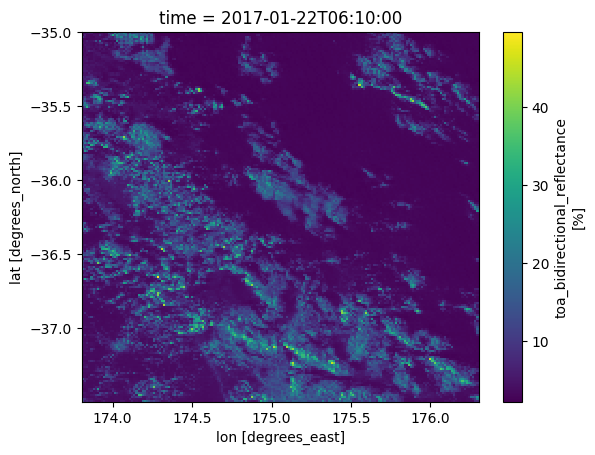

In [35]:
h8_ds.isel(time=105).plot()